# Phase 2 — Exploratory Data Analysis (EDA)

Goal: understand the churn dataset before building any model.
We're pulling data from the SQLite database we built in Phase 1 (not the raw CSV) — this mirrors how real teams work: the database is the single source of truth.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sqlalchemy import create_engine

# Make charts a bit nicer by default
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root
DB_PATH = PROJECT_ROOT / "data" / "processed" / "insighthub.db"

engine = create_engine(f"sqlite:///{DB_PATH}")
df = pd.read_sql("SELECT * FROM customers", engine)
print(df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


(7043, 21)


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. First look: shape, types, missing values

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   str    
 4   dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   str    
 7   multiplelines     7043 non-null   str    
 8   internetservice   7043 non-null   str    
 9   onlinesecurity    7043 non-null   str    
 10  onlinebackup      7043 non-null   str    
 11  deviceprotection  7043 non-null   str    
 12  techsupport       7043 non-null   str    
 13  streamingtv       7043 non-null   str    
 14  streamingmovies   7043 non-null   str    
 15  contract          7043 non-null   str    
 16  paperlessbilling  7043 non-null   str    
 17  paymen

In [3]:
# How many missing values per column?
df.isnull().sum().sort_values(ascending=False).head(10)

totalcharges      11
gender             0
seniorcitizen      0
partner            0
customerid         0
dependents         0
tenure             0
multiplelines      0
phoneservice       0
onlinesecurity     0
dtype: int64

In [4]:
df.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## 2. The target variable: churn
This is what we're eventually trying to predict. Always look at class balance early — it changes how you evaluate a model later.

churn
No     5174
Yes    1869
Name: count, dtype: int64
churn
No     73.5
Yes    26.5
Name: count, dtype: float64


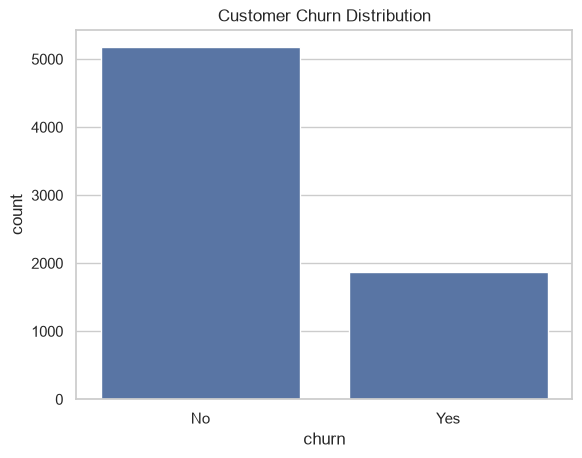

In [5]:
churn_counts = df["churn"].value_counts()
print(churn_counts)
print((churn_counts / len(df) * 100).round(1))

sns.countplot(data=df, x="churn")
plt.title("Customer Churn Distribution")
plt.show()

**Note:** if one class is much bigger than the other (e.g. 73% vs 27%), that's class imbalance. Keep this in mind — plain accuracy will be a misleading metric later, and we'll use precision/recall/ROC-AUC instead.

## 3. Numeric feature distributions

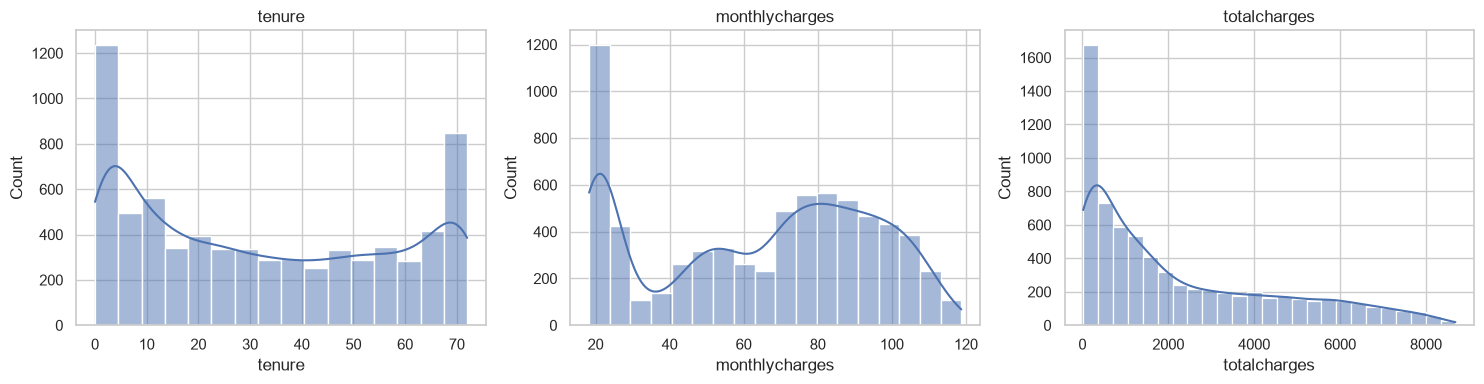

In [6]:
numeric_cols = ["tenure", "monthlycharges", "totalcharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. Churn rate by key categorical features
This is the visual version of the SQL queries you already ran.

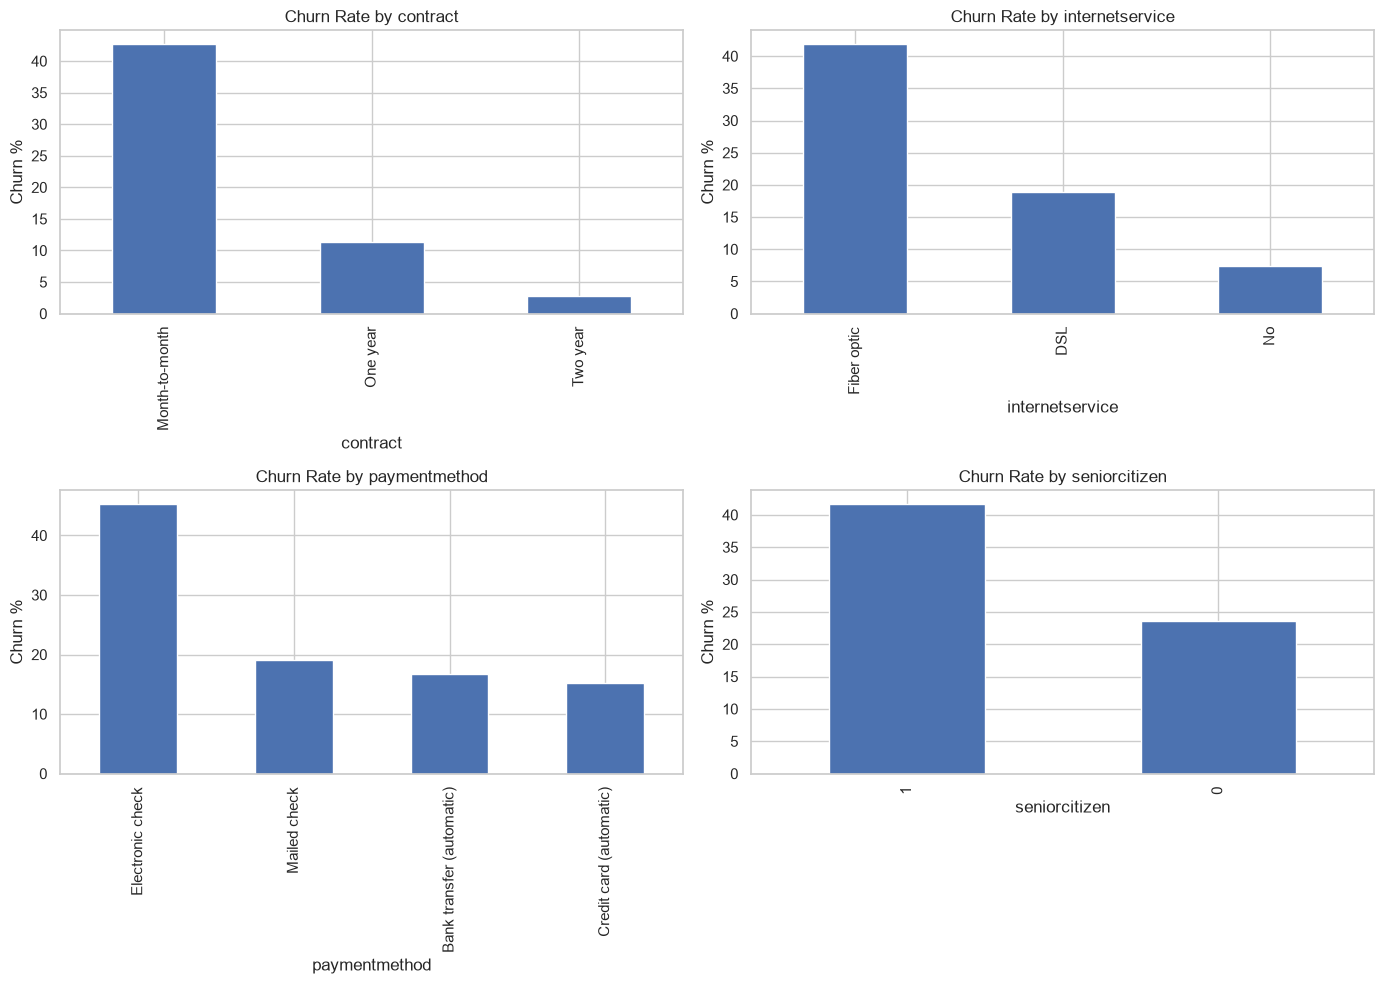

In [7]:
categorical_cols = ["contract", "internetservice", "paymentmethod", "seniorcitizen"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    churn_rate = df.groupby(col)["churn"].apply(lambda x: (x == "Yes").mean() * 100)
    churn_rate.sort_values(ascending=False).plot(kind="bar", ax=ax)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn %")

plt.tight_layout()
plt.show()

## 5. Numeric features vs. churn
Do tenure and monthly charges look different between churned and non-churned customers?

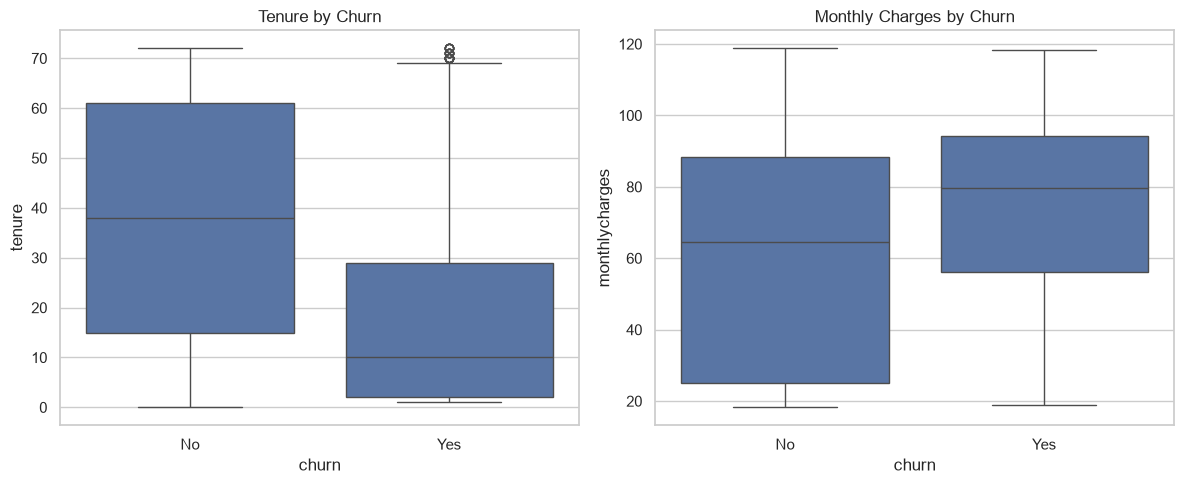

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="churn", y="tenure", ax=axes[0])
axes[0].set_title("Tenure by Churn")

sns.boxplot(data=df, x="churn", y="monthlycharges", ax=axes[1])
axes[1].set_title("Monthly Charges by Churn")

plt.tight_layout()
plt.show()

## 6. Correlation heatmap (numeric features only)

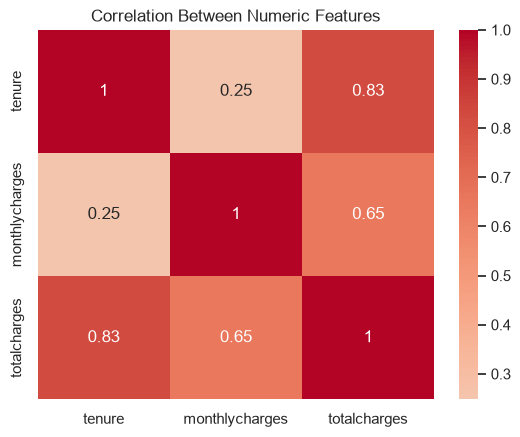

In [10]:
numeric_df = df[numeric_cols].copy()
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Numeric Features")
plt.show()

Month-to-month customers churn much more frequently than customers on one-year or two-year contracts, suggesting that contract commitment is strongly associated with retention.
Newer customers with low tenure are more likely to churn than long-term customers, indicating that the early customer lifecycle is a high-risk period.
Customers with higher monthly charges tend to show higher churn, suggesting that pricing or perceived value may be important factors in retention.
Internet service, payment method, and additional services such as Tech Support and Online Security show noticeable differences in churn rates, making them useful variables for customer segmentation.
Churn is moderately imbalanced—roughly 27% of customers churn—so accuracy alone would not be a good evaluation metric; precision, recall, F1, ROC-AUC, PR-AUC, and business impact should also be considered.